<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 4
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
Molecular dynamics
</h2>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

def maxwell_boltzmann(v, T, m=1.0):
  coeff = 4 * np.pi * (m / (2 * np.pi * T))**1.5
  f_MB = coeff * v**2 * np.exp(-m * v**2 / (2 * T))
  return f_MB

def plot_energy(data_p, data_k, data_e):
  N = data_e[:, 0]
  plt.errorbar(N, data_p[:, 2], yerr=data_p[:, 3], color='crimson', label='Potential', fmt='o-')
  plt.errorbar(N, data_k[:, 2], yerr=data_k[:, 3], color='royalblue', label='Kinetic', fmt='o-')
  plt.errorbar(N, data_e[:, 2], yerr=data_e[:, 3], color='seagreen', label='Total', fmt='o-')
  plt.xlabel("#Blocks")
  plt.ylabel("Energy")
  plt.title("Averages over blocks")
  plt.grid(True)
  plt.legend()
  plt.show()

def plot_block_av(data_, color, prop):
  N = data_[:, 0]
  plt.errorbar(N, data_[:, 2], yerr=data_[:, 3], fmt='-o', color=color)
  plt.xlabel("#Blocks")
  plt.ylabel(prop)
  plt.title(f"Average {prop} over blocks")
  plt.grid(True)
  plt.show()

def subplots(ax, x, y, er, ylabel, prop, label, color, markersize=None):
  if markersize==None:
    ax.errorbar(x, y, yerr=er, color=color, label=label, fmt='-o')
  else:
    ax.errorbar(x, y, yerr=er, color=color, label=label, fmt='-o', ms=markersize)
  ax.set_xlabel("#Block")
  ax.set_ylabel(ylabel)
  ax.set_title(f"Average {prop} over blocks")
  ax.grid(True)
  if label!="": ax.legend()

def comparing_plots(ax, N_for, N_bac, data_V_for, data_V_bac, data_T_for, data_T_bac, reverse_V=False, reverse_T=False, marker=None):
  U_forward=data_V_for[:,1]
  errUf=data_V_for[:,3]
  U_backwards=data_V_bac[:,1]
  errUb=data_V_bac[:,3]
  T_forward=data_T_for[:,1]
  errTf=data_T_for[:,3]
  T_backwards=data_T_bac[:,1]
  errTb=data_T_bac[:,3]
  if reverse_V:
    subplots(ax[0], N_bac[::-1], U_backwards, errUb, "<U>", "Average potential energy through blocks" , "backwards in time", "royalblue", marker)
  else:
    subplots(ax[0], N_bac, U_backwards, errUb, "<U>", "Average potential energy through blocks" , "backwards in time", "royalblue", marker)
  subplots(ax[0], N_for, U_forward, errUf, "<U>", "Average potential energy through blocks" , "forward in time", "crimson", marker)
  if reverse_T:
    subplots(ax[1], N_bac[::-1], T_backwards, errTb, "<T>", "Average temperature through blocks" , "backwards in time", "royalblue", marker)
  else:
    subplots(ax[1], N_bac, T_backwards, errTb, "<T>", "Average temperature through blocks" , "backwards in time", "royalblue", marker)
  subplots(ax[1], N_for, T_forward, errTf, "<T>", "Average temperature through blocks" , "forward in time", "crimson", marker)

# Statistical physics

Statistical physics is the branch of physics that bridges the microscopic world with the macroscopic one using statistics.

Even the simplest macroscopic system contains on the order of particles, making it not only impossible but also meaningless to track the motion of each individual constituent when studying the system as a whole.

A system can be described in terms of:

- **Macroscopic state**: the real-world measurable one, caracterized by variables such as energy E, temperature T, volume V, number of particles N.

- **Microscopic state**: defined as a configuration of points in the phase spase (q,p). For every macroscopic state, there exist many compatible microscopic configurations.

A good way to evaluate macro quantities based on the microstate is to compute the ensemble average, namely an average over all the possible micro-configurations compatible with the macro-state at a fixed time instant. For a generic observable O:
$$
\braket{O}=\int dq^{3N}dp^{3N}O(\mathbf{q},\mathbf{p})\rho(\mathbf{q}, \mathbf{p})
$$
Where $\rho(\mathbf{q}, \mathbf{p})$ is the representative points density in the phase space. Another, more realistic quantity, is the time average, which corresponds to what it's actually measured in experiments. Given initial conditions $O(\mathbf{q}(t_0), \mathbf{p}(t_0))=O_0$, it is defined as:
$$
\braket{O}=\frac{1}{\Delta t}\int_{t_0}^{t_0+\Delta t} dtO(\mathbf{q}(t),\mathbf{p}(t)).
$$
The ergodic hypothesis states that, for $\Delta t\to\infty$ the ensemble average and the time average coincide.

We are going to use this property in our simulations, because in practise only one single trajectory is computed. Therefore, the ergodic hypothesis allows to extract meaningful macroscopic information from this single time evolution, assuming that it effectively samples the relevant regions of phase space.

The idea of molecular dynamics is to test statistical physics by simulating the time dependent behaviour of a system of particles. Laws of motion are used to simulate every particle position and velocity at each time step, with the aim to extract macroscopic quantities from the system by using statistical physics.

The code implements a simulation of the particles using an Hamiltonian based on the Lennard-Jones potential, and the movements are simulated using the Verlet algorithm, based on taylor expantion of the position vector.


<p style="color: blue; font-size: 25px; font-weight: bold;">
4.1/4.2
</p>

For an ideal gas at fixed temperature, at equilibrium, statistical physics provides a way to get the particles velocity distrubion, and it's called the Maxwell-Boltzmann distribution.

If all the considerations done before hold, by starting a molecular dynamics simulation with a gas in an fcc (crystalline) initial configuration of molecules and with initial delta distribution for velocities, after a certain number of time steps, the system equilibrates and evolves during the simulation to reach the theoretical configuration of a gas, which is described by the Maxwell-Boltzmann distribution. This is what's been done with the argon parameters: $\sigma=0.34\ nm$,$\epsilon/k_B=120\ K$, $m=39.948\ amu$ in gas-phase conditions $\rho^*=0.05,\ T^*=2.0$.

To achieve the initial delta distribution, a loop iterates over the total number of particles, and the velocity components are set based on the integer division between the particle index (i) and 6 (representing the six possible positive and negative directions in 3D space). Since the total number of particle is 108, the total momentum of the system is automatically zero and thus no velocity rescaling is required.

The simulation use the following condition:
```text
SIMULATION_TYPE        0
DISTRIBUTION_TYPE      1
RESTART                0
TEMP                   2.0
NPART                  108
RHO                    0.05
R_CUT                  5.0
DELTA                  0.001
NBLOCKS                20
NSTEPS                 2000

ENDINPUT
```

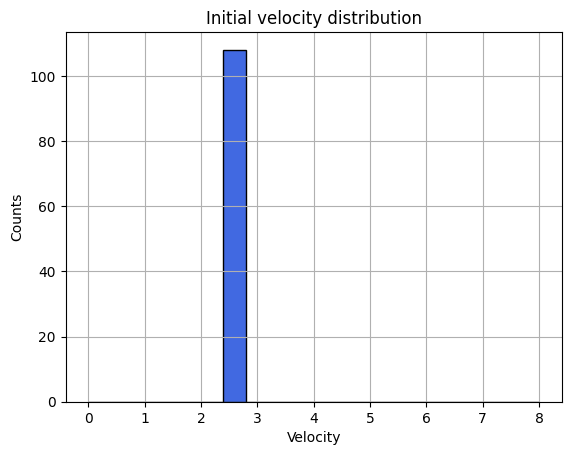

In [17]:
v_in = np.loadtxt("./EX_4.2/OUTPUT_2000/initial_velocity_distr.dat", comments="#")
v = v_in[:, 0]
count = v_in[:, 1]
bin_width = v[1] - v[0]
plt.bar(v, count, width=bin_width, edgecolor='black', color='royalblue')
plt.xlabel("Velocity")
plt.ylabel("Counts")
plt.title("Initial velocity distribution")
plt.grid(True)
plt.show()

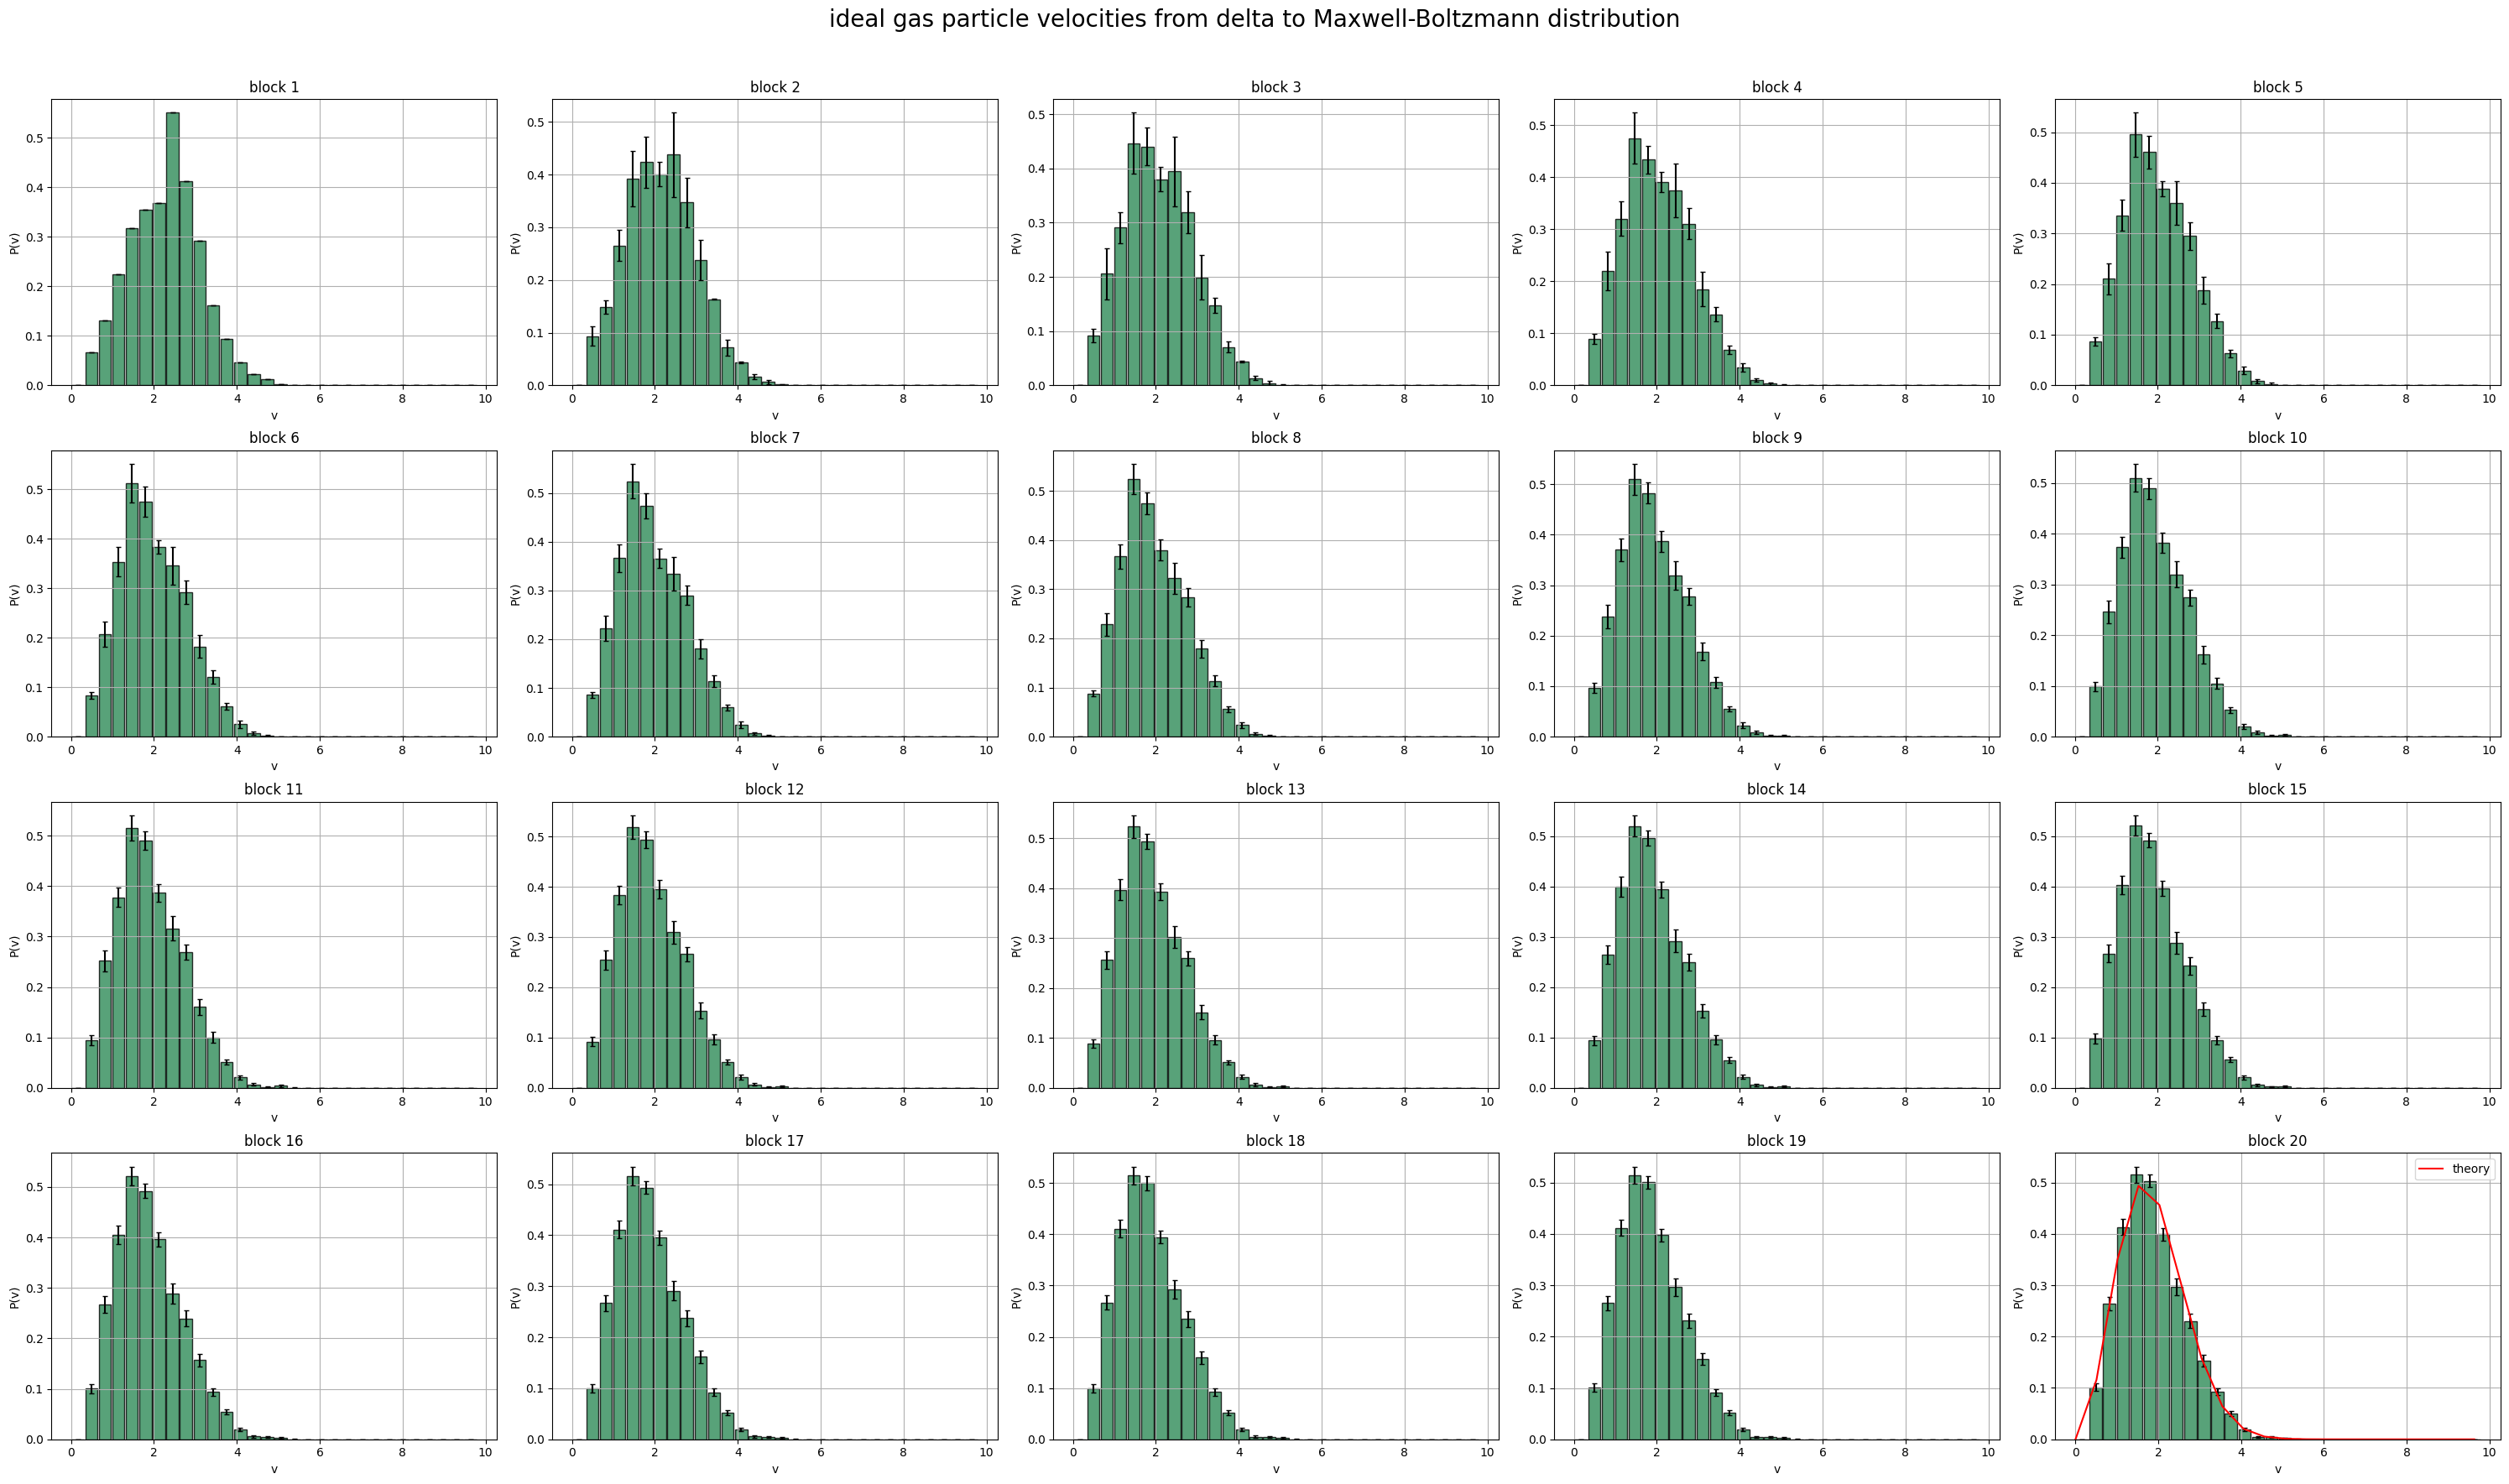

In [18]:
data = np.loadtxt("./EX_4.2/OUTPUT_2000/pofv.dat")
Temp = np.loadtxt("./EX_4.2/OUTPUT_2000/temperature.dat")
Final_T=Temp[-1, 2]
blocks=np.unique(data[:,0]) 
#plot
fig, axes= plt.subplots(4,5, figsize=(30,18))
axes=axes.flatten()
for blk in range (len(blocks)):
    #ffilter current block's data
        current_block=data[data[:,0]==blk+1]
        v=current_block[:,1]
        pofv=current_block[:,2]
        err=current_block[:,3]
        width = np.min(np.diff(v)) * 0.9 if len(v) > 1 else 1.0
        axes[blk].bar(v, pofv, width=width, color='seagreen', edgecolor='black', alpha=0.8)
        axes[blk].errorbar(v, pofv, yerr=err, fmt='none', ecolor= 'black', capsize=2)
        axes[blk].set_title(f"block {blk+1}")
        axes[blk].grid(True)
        axes[blk].set_xlabel("v")
        axes[blk].set_ylabel("P(v)")
#plot theoretical function 
x=np.linspace(0, np.max(v), 20)
y=maxwell_boltzmann(x, Final_T)
axes[-1].plot(x,y, color='r', label="theory")
axes[-1].legend()
fig.suptitle('ideal gas particle velocities from delta to Maxwell-Boltzmann distribution', fontsize=20)
plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

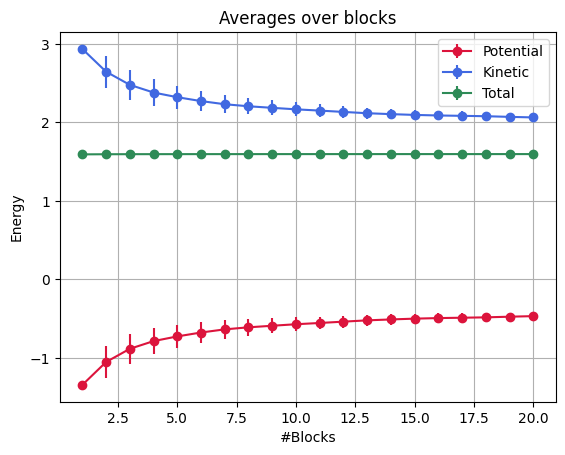

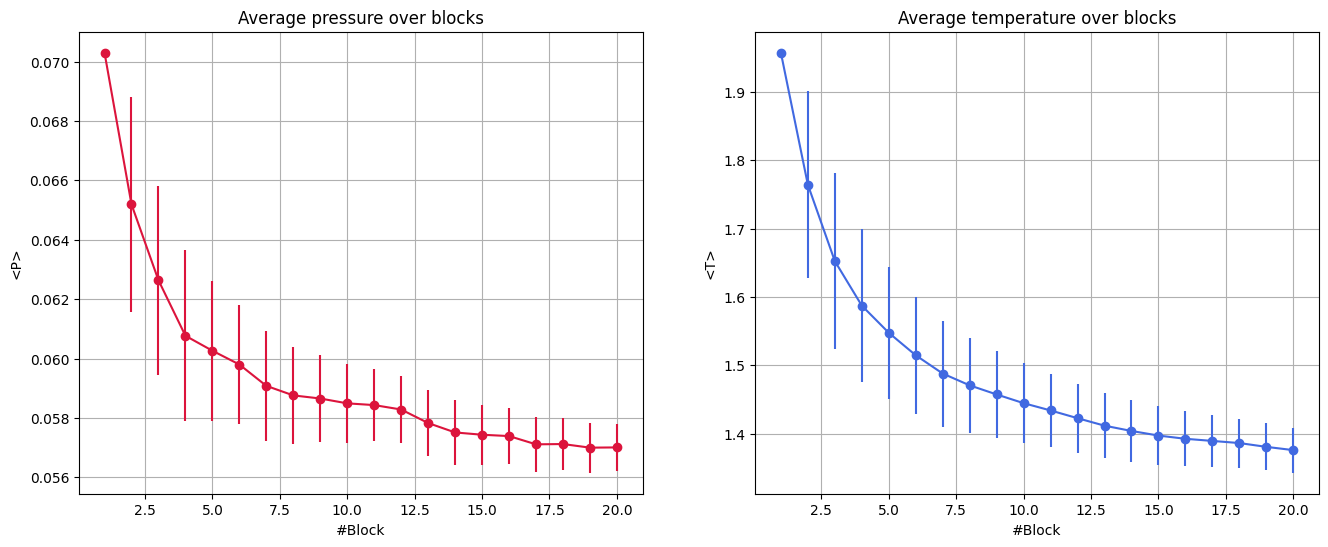

In [19]:
data_P = np.loadtxt("./EX_4.2/OUTPUT_2000/potential_energy.dat", comments="#")
data_K = np.loadtxt("./EX_4.2/OUTPUT_2000/kinetic_energy.dat", comments="#")
data_E = np.loadtxt("./EX_4.2/OUTPUT_2000/total_energy.dat", comments="#")
data_press = np.loadtxt("./EX_4.2/OUTPUT_2000/pressure.dat", comments="#")
blocks = data_P[:, 0]

plot_energy(data_P, data_K, data_E)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax = ax.flatten()
subplots(ax[0], blocks, data_press[:, 2], data_press[:, 3], "<P>", "pressure", "", "crimson")
subplots(ax[1], blocks, Temp[:, 2], Temp[:, 3], "<T>", "temperature", "", "royalblue")

# Conclusions

The initial state, defined by the highly ordered Dirac velocity distribution, quickly relaxes towards the more characteristic Maxwell-Boltzmann ensemble. This evolution illustrates the Second Law of Thermodynamics, which asserts that isolated systems evolve spontaneously from low-probability, low-entropy configurations (highly ordered) to more probable, high-entropy states (disordered equilibrium).

The previous figures provide further insight into the ensemble's relaxation process. As the simulation begins, the system undergoes both a structural expansion (starting from a high-density FCC lattice occupying half the volume) with decreasing pressure and a subsequent cooling process (the temperature decreases as the kinetic energy is converted into potential energy due to the expansion against repulsive forces).

<p style="color: blue; font-size: 25px; font-weight: bold;">
4.3: Time inversion
</p>

The Verlet algorithm is symmetric with respect to the time variable. Given this property, one might expect that a molecular dynamics simulation could be reversed in time without issues.

The concept of time reversal in Molecular Dynamics requires careful phrasing. Molecular Dynamics (MD) is intrinsically time-reversible because the underlying equations of motion (Newton's laws) are symmetric with respect to time reversal ($t\to-t$). However, the thermodynamic evolution is not (Second principle).

We aim to invert the simulation to return to the low-entropy initial configuration described in Section 4.2. To achieve this, we will utilize the last two configuration output files generated during the equilibration run. Specifically, the file OUTPUT/conf-1.xyz, corresponding to the second-to-last step of the equilibration run, is copied to INPUT/config.xyz to define the system's initial configuration for the backward simulation. Conversely, the file OUTPUT/config.xyz, which holds the final configuration of the previous simulation, is copied to INPUT/conf-1.xyz to represent the configuration at the previous timestep.

# 5000 steps

The inverse simulations have the following input:
```text
SIMULATION_TYPE        0
DISTRIBUTION_TYPE      0
RESTART                1
TEMP                   1.42442
NPART                  108
RHO                    0.05
R_CUT                  5.0
DELTA                  0.001
NBLOCKS                5000
NSTEPS                 1

ENDINPUT
```
Where we have setted the starting temperature to the one the forward simualation stop at which.
It's important to set `DISTRIBUTION_TYPE` at zero, because in the source code if the type is 1, the position are imposed in the halfside of the box, so it is an unfair compression.

In the backward simulation, the potential is plotted with the x-axis reversed, allowing a clear and accurate overlap with the forward simulation. In contrast, for the temperature case, the axes are kept in the same orientation for both simulations.

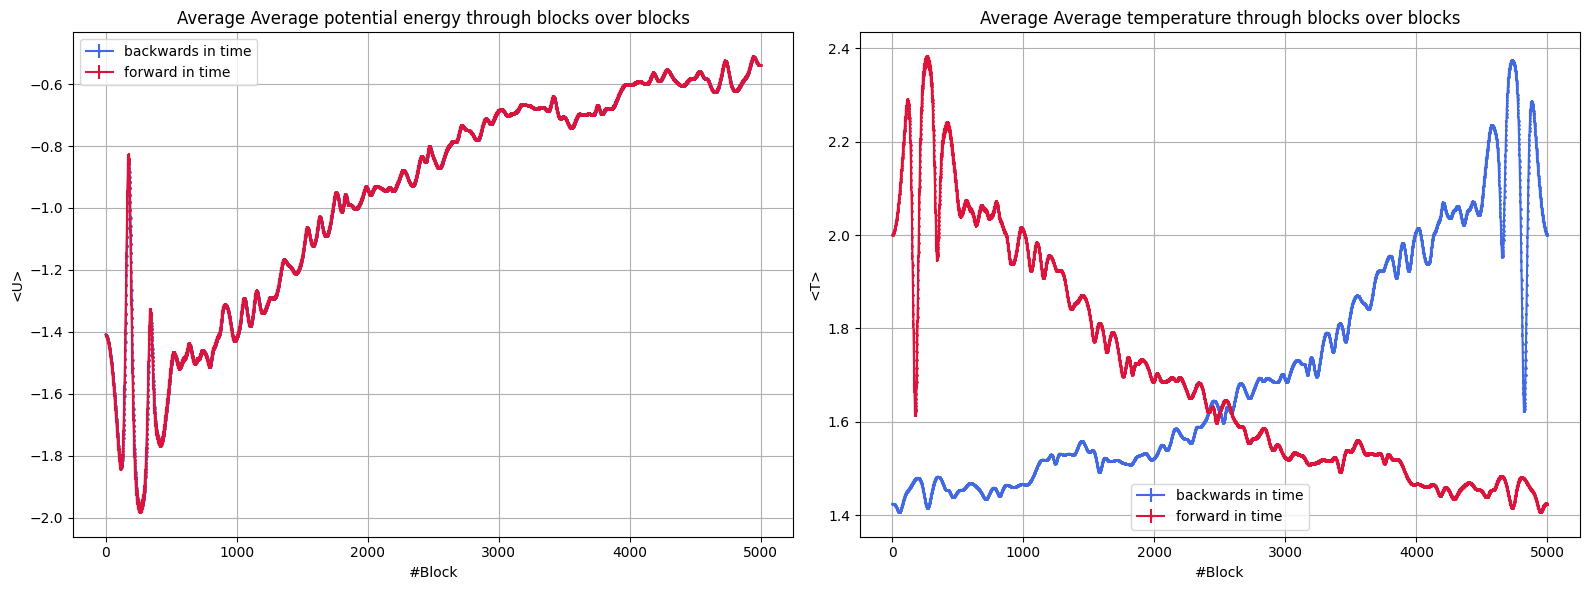

In [20]:
dataU_forward=np.loadtxt("./EX_4.2/OUTPUT_5000/potential_energy.dat")
dataT_forward=np.loadtxt("./EX_4.2/OUTPUT_5000/temperature.dat")
dataU_backwards=np.loadtxt("./EX_4.3/OUTPUT_5000/potential_energy.dat")
dataT_backwards=np.loadtxt("./EX_4.3/OUTPUT_5000/temperature.dat")
N=np.arange(0,dataU_forward.shape[0])

fig, ax= plt.subplots(1,2, figsize=(16,6))
ax=ax.flatten()
comparing_plots(ax, N, N, dataU_forward, dataU_backwards, dataT_forward, dataT_backwards, True, marker=1)
plt.tight_layout()
plt.show()

| Forward Simulation | Backward Simulation |
| :---: | :---: |
| ![Forward](./EX_4.2/OUTPUT_5000/forward_5000.gif) | ![Backward](./EX_4.3/OUTPUT_5000/backward_5000.gif) |

As can be seen, the system returns to its initial state, as evidenced by the temperature and potential plots, which mirror each other. Furthermore, the video clearly demonstrates this behavior. This confirms our expectation of the time-reversal symmetry of the Verlet algorithm.

# 50000 steps

Now that we have tested the reversibility of the system, let us repeat the simulation using ten times as many time steps.

This inversion simulations have the following input:
```text
SIMULATION_TYPE        0
DISTRIBUTION_TYPE      0
RESTART                1
TEMP                   1.28422
NPART                  108
RHO                    0.05
R_CUT                  5.0
DELTA                  0.001
NBLOCKS                50000
NSTEPS                 1

ENDINPUT
```

In this case, both the temperature and potential plots of the backward simulation are displayed with the x-axis reversed. This makes the overlap with the forward simulation much more evident, allowing us to clearly identify the region where the two trajectories coincide. As the simulation progresses, the curves gradually begin to separate, indicating the point at which the backward simulation starts to deviate from the forward one and eventually loses agreement with it.

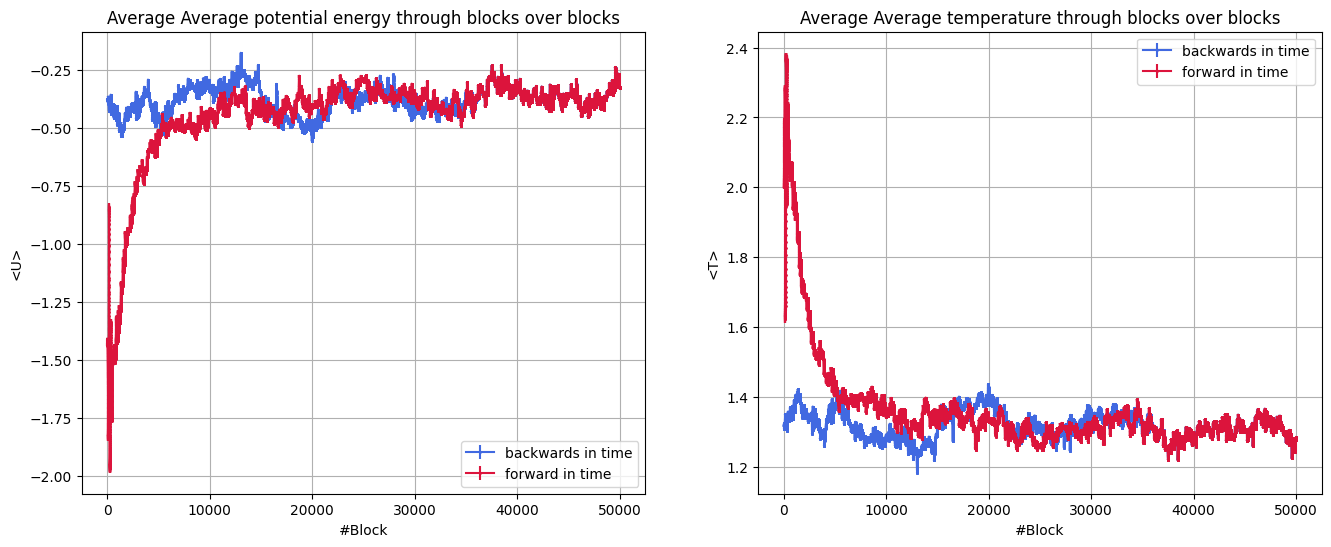

In [21]:
dataU_forward=np.loadtxt("./EX_4.2/OUTPUT_50000/potential_energy.dat")
dataT_forward=np.loadtxt("./EX_4.2/OUTPUT_50000/temperature.dat")
dataU_backwards=np.loadtxt("./EX_4.3/OUTPUT_50000/potential_energy.dat")
dataT_backwards=np.loadtxt("./EX_4.3/OUTPUT_50000/temperature.dat")
N=np.arange(0,dataU_forward.shape[0]) #get number of blocks

fig, ax= plt.subplots(1,2, figsize=(16,6))
ax=ax.flatten()
comparing_plots(ax, N, N, dataU_forward, dataU_backwards, dataT_forward, dataT_backwards, True, True,marker=1)


| Forward Simulation | Backward Simulation |
| :---: | :---: |
| ![Forward](./EX_4.2/OUTPUT_50000/forward_50000.gif) | ![Backward](./EX_4.3/OUTPUT_50000/backward_50000.gif) |

Finally, we present the results of a simulation performed in the forward direction for only 5,000 time steps, but wth a backward one is carried out for a larger number of time steps, starting from the final configuration of the 5000-step forward simulation. As expected, the system initially retraces its previous evolution before continuing beyond the original starting point.

```text
SIMULATION_TYPE        0
DISTRIBUTION_TYPE      0
RESTART                1
TEMP                   1.42442
NPART                  108
RHO                    0.05
R_CUT                  5.0
DELTA                  0.001
NBLOCKS                10000
NSTEPS                 1

ENDINPUT
``` 

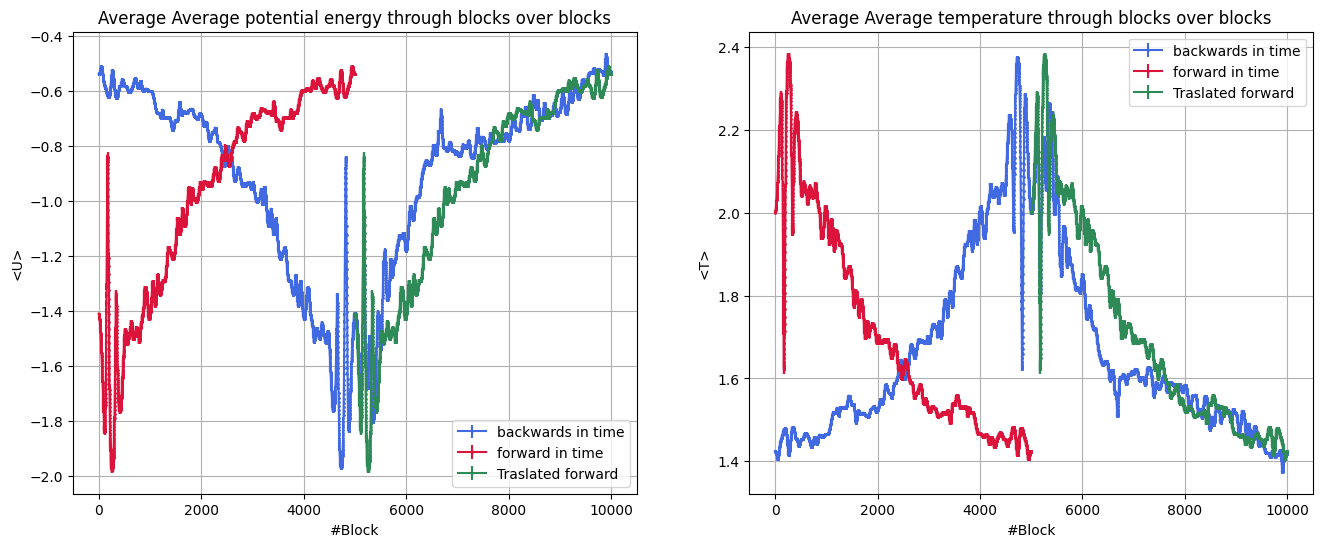

In [22]:
dataU_forward=np.loadtxt("./EX_4.2/OUTPUT_5000/potential_energy.dat")
dataT_forward=np.loadtxt("./EX_4.2/OUTPUT_5000/temperature.dat")
dataU_backwards=np.loadtxt("./EX_4.3/OUTPUT_oltre/potential_energy.dat")
dataT_backwards=np.loadtxt("./EX_4.3/OUTPUT_oltre/temperature.dat")
N_for = np.arange(0, dataU_forward.shape[0])
N_back = np.arange(0, dataU_backwards.shape[0])

fig, ax= plt.subplots(1,2, figsize=(16,6))
ax=ax.flatten()
comparing_plots(ax, N_for, N_back, dataU_forward, dataU_backwards, dataT_forward, dataT_backwards, marker=1)
subplots(ax[0], N_for+5000, dataU_forward[:, 1], dataU_forward[:, 3], "<U>", "Average potential energy through blocks", "Traslated forward", "seagreen", markersize=1)
subplots(ax[1], N_for+5000, dataT_forward[:, 1], dataT_forward[:, 3], "<T>", "Average temperature through blocks", "Traslated forward", "seagreen", markersize=1)

| Forward Simulation | Backward Simulation |
| :---: | :---: |
| ![Forward](./EX_4.2/OUTPUT_5000/forward_5000.gif) | ![Backward](./EX_4.3/OUTPUT_oltre/backward_oltre.gif) |

<p style="color: green; font-size: 25px; font-weight: bold;">
Conclusions
</p>

From the results of the previous simulation, we can draw the following conclusions:
- the one with 5,000 steps proves the invariance of the equations of motions respect to time reversal operation. One can also undderstand the second law of thermodynamics: It states that the probability of obtaining a microscopic configuration with all velocities reversed, which would allow the system to return to its initial state, is extremely low. However, if we are able to reverse all individual velocities, the system will return to its initial state, and that's what we have done in this excercise. The time-reversal symmetry of the system is therefore numerically verified for the 5,000-step case, as can be observed from the values of the physical properties of the system and from the video.

- In the simulation with 50,000 number of steps, however, this behavior no longer appears to be verified. The invariance of the equations of motion should still hold, since, given the symmetry and the initial conditions, the Cauchy theorem ensures that the evolution is completely determined, and therefore the final state as well. The interesting point concerns precisely this aspect, we are not solving analytically the equations of motion, but using a numerical integration algorithm, which introduce finite precision errors. This error made our system chaotic, and in a caotic systems, close but differents initial conditions leads to exponential divergent trajectories (Lyapunov instability). So, in the backward simulation, the system begins to explore configurations little differents from the forward one, and in particular, in the shorter simulation, this exponential divergence cannot yet be observed meaning that the exponential growth of the deviation has not started to become evident. Conversely, in the longer one, the exponential divergence becomes evident. Furthermore, it can be observed that the deviation begins to emerge after a number of steps on the order of 10,000. 

- In the last simulation, in which the time-reversed evolution is carried out for a larger number of steps than the forward simulation, we show what happens once the system reaches its initial state and the backward evolution is continued further. What can be observed is that the system starts evolving again in the same way as it did during the forward simulation. Moreover, since we are still within the limit of 10,000 steps, we observe that the final point of the extended backward simulation coincides with the final point reached by the longer forward simulation. The evolution of the thermodynamic properties shows only small deviations, without exhibiting an exponential divergence.